In [1]:
# import os
import pandas as pd
import geopandas as gpd

# for plotting the spatial relationships
from shapely.geometry import LineString

## the pysal weights and Moran's I calculation
# from pysal.lib import weights
from libpysal import weights
#from libpysal.weights import higher_order
#from pysal.explore import esda  # esda: Exploratory Spatial Data Analysis
import esda
from splot.esda import moran_scatterplot

# Plotting functions
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from tqdm import tqdm

In [5]:
weights.Queen, weights.higher_order

(libpysal.weights.contiguity.Queen,
 <function libpysal.weights.util.higher_order(w, k=2, **kwargs)>)

In [3]:
#!pip install pysal

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 12.8 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 6.2 MB/s eta 0:00:001 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 14.9 MB/s eta 0:00:0031m23.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 45.4 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 39.3 MB/s eta 0:00:00m eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 41.6 MB/s eta 0:00:00m eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 41.1 MB/s eta 0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
df = pd.read_csv('../resources/ODIO_all_202306.csv.xz', index_col=0)  # <-- new file, train and bus ridership in SG
df.head()

,year_month,Hour_of_day,subz,plna,regn,Weekday_incoming,Weekday_outgoing,Weekend_incoming,Weekend_outgoing
ind,,,,,,,,,
0,202306,4,BUKIT MERAH,BUKIT MERAH,CENTRAL REGION,0.681818,0.045455,0.625,0.000
1,202306,4,NORTH COAST,WOODLANDS,NORTH REGION,0.045455,0.090909,0.000,0.000
2,202306,4,TAMPINES EAST,TAMPINES,EAST REGION,0.045455,0.000000,0.000,0.250
3,202306,5,ADMIRALTY,SEMBAWANG,NORTH REGION,25.000000,49.681818,14.625,31.125
4,202306,5,ALEXANDRA HILL,BUKIT MERAH,CENTRAL REGION,77.500000,78.863636,54.125,49.375


In [7]:
df2 = df[df['Hour_of_day']>=6]  # get morning peak
df2 = df2[df2['Hour_of_day']<9]  # get morning peak, before office hour
len(df2)

908

In [8]:
df3 = df2.groupby('subz')[['Weekday_incoming', 'Weekday_outgoing', 'Weekend_incoming', 'Weekend_outgoing']].sum().reset_index()
df3

,subz,Weekday_incoming,Weekday_outgoing,Weekend_incoming,Weekend_outgoing
0,ADMIRALTY,655.545455,921.818182,504.875,709.125
1,AIRPORT ROAD,404.090909,20.500000,109.125,17.250
2,ALEXANDRA HILL,2454.545455,1595.863636,1219.500,1182.125
3,ALEXANDRA NORTH,198.272727,132.818182,82.750,67.875
4,ALJUNIED,8573.545455,11411.363636,7331.000,9095.125
...,...,...,...,...,...
298,YISHUN SOUTH,1736.318182,4001.590909,1324.500,2643.875
299,YISHUN WEST,7358.000000,14640.136364,6660.625,9128.375
300,YUHUA EAST,1550.863636,2500.045455,1730.250,1905.875
301,YUHUA WEST,1789.181818,2517.181818,1798.125,2149.625


look at the data, all are Poisson-like

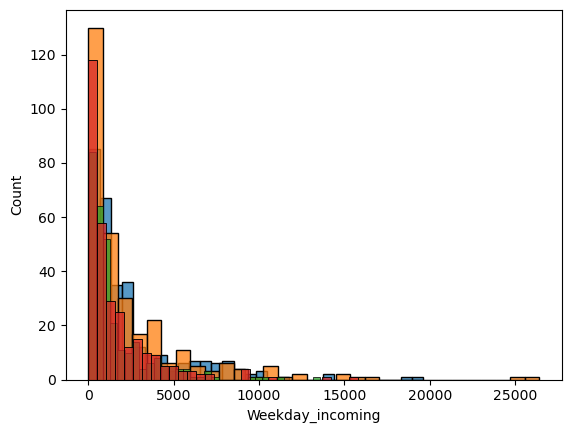

In [31]:
cols = ['Weekday_incoming', 'Weekday_outgoing', 'Weekend_incoming', 'Weekend_outgoing']
for col in cols:
    sns.histplot(df3[col])

how about log-transform?

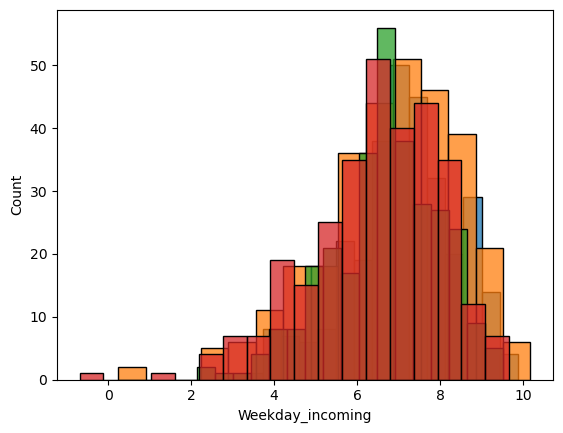

In [32]:
cols = ['Weekday_incoming', 'Weekday_outgoing', 'Weekend_incoming', 'Weekend_outgoing']
for col in cols:
    sns.histplot(np.log(df3[col]))

In [33]:
cols = ['Weekday_incoming', 'Weekday_outgoing', 'Weekend_incoming', 'Weekend_outgoing']
for col in cols:
    df3[col+'_log'] = np.log(df3[col]+1)  # +1 to avoid log(0) NaN problem

        SUBZONE_N       PLN_AREA_N        REGION_N REGION_C  \
0    MARINA SOUTH     MARINA SOUTH  CENTRAL REGION       CR   
1    PEARL'S HILL           OUTRAM  CENTRAL REGION       CR   
2       BOAT QUAY  SINGAPORE RIVER  CENTRAL REGION       CR   
3  HENDERSON HILL      BUKIT MERAH  CENTRAL REGION       CR   
4         REDHILL      BUKIT MERAH  CENTRAL REGION       CR   

                                            geometry  
0  POLYGON ((31495.560 30140.012, 31980.957 29671...  
1  POLYGON ((29092.275 30021.888, 29119.641 30006...  
2  POLYGON ((29932.332 29879.120, 29947.317 29858...  
3  POLYGON ((27131.276 30059.727, 27088.334 29709...  
4  POLYGON ((26451.027 30396.458, 26440.474 30361...  


<Axes: >

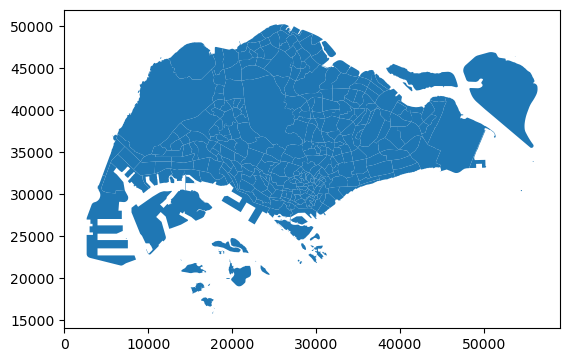

In [5]:
subz = gpd.read_file('../resources/MP14_SUBZONE_WEB_PL.zip')  # <-- new file, Master Plan 2014
subz = subz.to_crs('epsg:3414')
subz = subz[['SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'REGION_C', 'geometry']]
print(subz.head())
subz.plot()

In [11]:
len(subz), len(df3)   # ridership data has less subzones

(323, 303)

In [34]:
df_merged = subz.merge(df3, left_on='SUBZONE_N', right_on='subz')
len(df_merged)  # all subzones from ridership dataset successfully joined, some empty subzones are ignored

303

In [35]:
df_merged.columns

Index(['SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'REGION_C', 'geometry', 'subz',
       'Weekday_incoming', 'Weekday_outgoing', 'Weekend_incoming',
       'Weekend_outgoing', 'Weekday_incoming_log', 'Weekday_outgoing_log',
       'Weekend_incoming_log', 'Weekend_outgoing_log'],
      dtype='object')

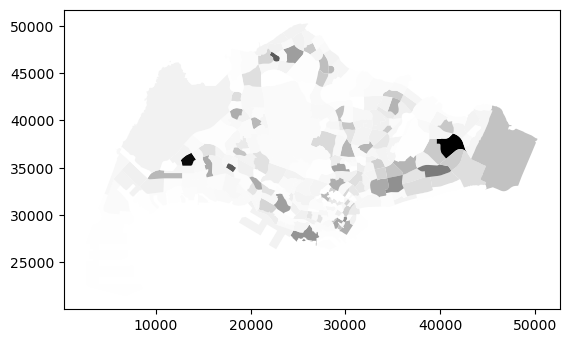

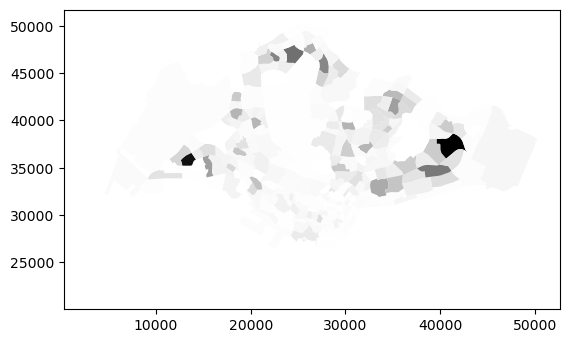

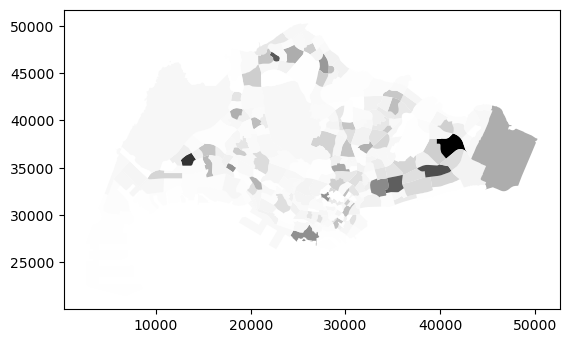

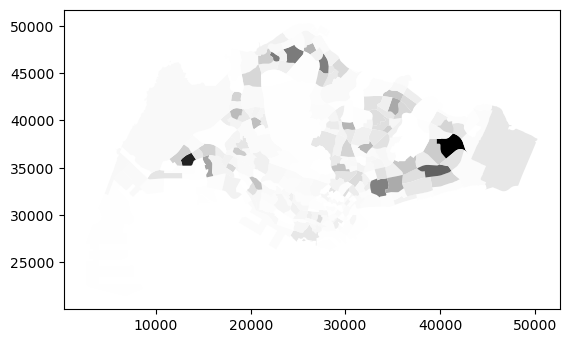

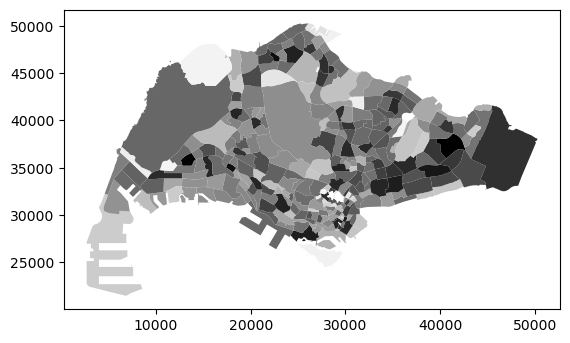

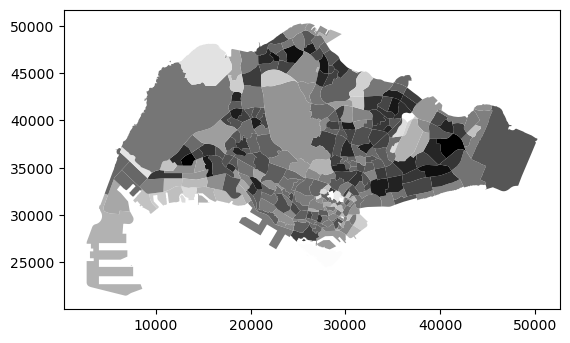

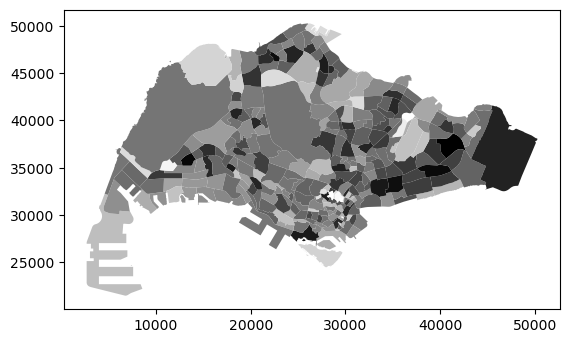

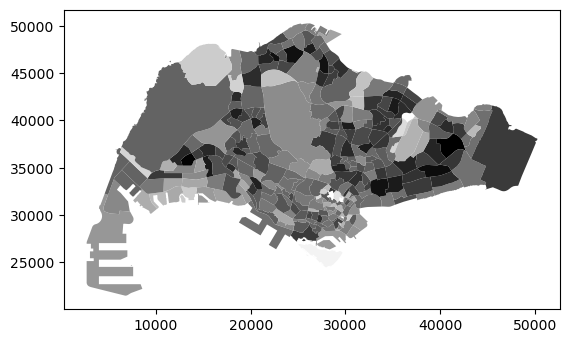

In [36]:
cols8 = ['Weekday_incoming', 'Weekday_outgoing', 'Weekend_incoming',
       'Weekend_outgoing', 'Weekday_incoming_log', 'Weekday_outgoing_log',
       'Weekend_incoming_log', 'Weekend_outgoing_log']

for col in cols8:
    df_merged.plot(col, cmap='Greys')  # just a quick mapping

## how to put them together?
# fig, axg = plt.subplots(4, 2, figsize=(10, 12))


In [37]:
df_merged.head()

,SUBZONE_N,PLN_AREA_N,REGION_N,REGION_C,geometry,subz,Weekday_incoming,Weekday_outgoing,Weekend_incoming,Weekend_outgoing,Weekday_incoming_log,Weekday_outgoing_log,Weekend_incoming_log,Weekend_outgoing_log
0,MARINA SOUTH,MARINA SOUTH,CENTRAL REGION,CR,"POLYGON ((31495.560 30140.012, 31980.957 29671...",MARINA SOUTH,252.409091,36.545455,714.125,133.750,5.535005,3.625552,6.572457,4.903421
1,PEARL'S HILL,OUTRAM,CENTRAL REGION,CR,"POLYGON ((29092.275 30021.888, 29119.641 30006...",PEARL'S HILL,586.409091,451.681818,406.625,405.375,6.375721,6.115189,6.010348,6.007276
2,BOAT QUAY,SINGAPORE RIVER,CENTRAL REGION,CR,"POLYGON ((29932.332 29879.120, 29947.317 29858...",BOAT QUAY,351.681818,81.181818,179.500,58.000,5.865566,4.408934,5.195731,4.077537
3,HENDERSON HILL,BUKIT MERAH,CENTRAL REGION,CR,"POLYGON ((27131.276 30059.727, 27088.334 29709...",HENDERSON HILL,1127.090909,1685.863636,1205.125,1516.125,7.028282,7.430626,7.095168,7.324572
4,REDHILL,BUKIT MERAH,CENTRAL REGION,CR,"POLYGON ((26451.027 30396.458, 26440.474 30361...",REDHILL,3753.363636,3422.954545,2617.250,2099.375,8.230674,8.138551,7.870261,7.649871


let's try standardizing them

In [38]:
def standardize(pd_series):
    #m = pd_series.mean()
    #s = pd_series.std()
    #vs = [(v-m)/s for v in pd_series]
    standardized_series = (pd_series - pd_series.mean()) / pd_series.std()

    return standardized_series

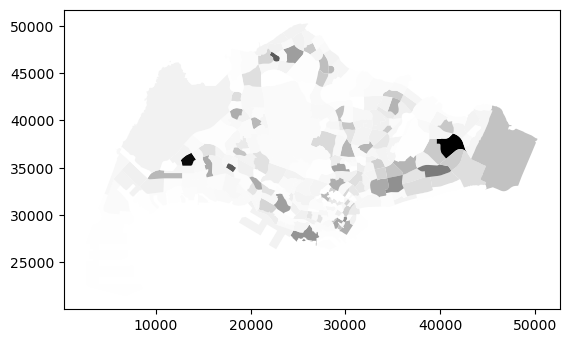

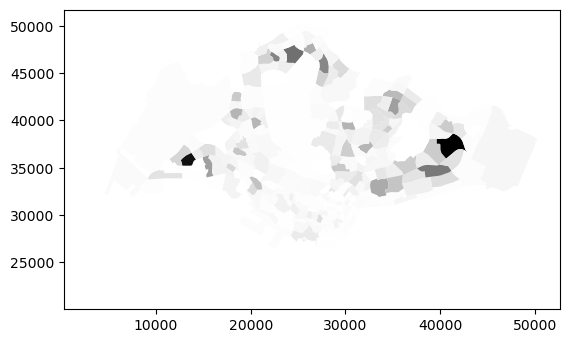

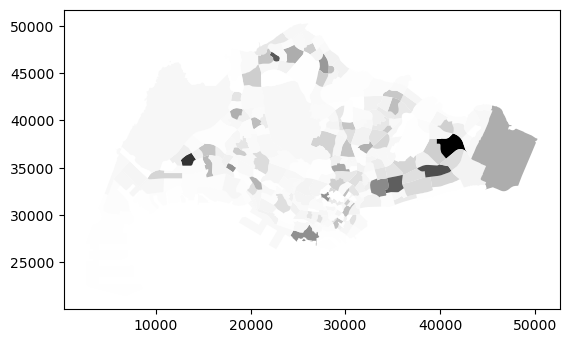

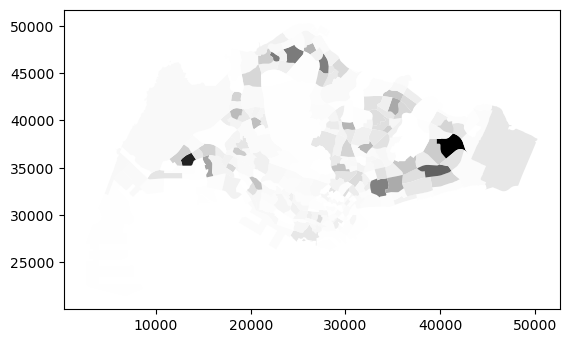

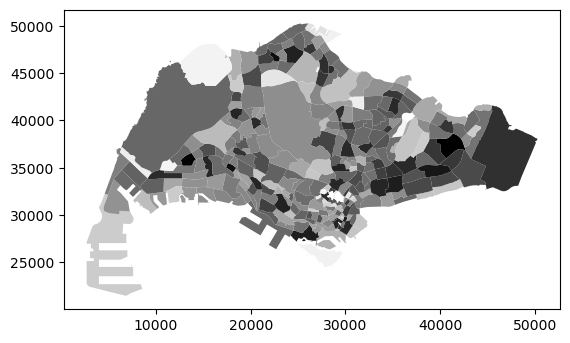

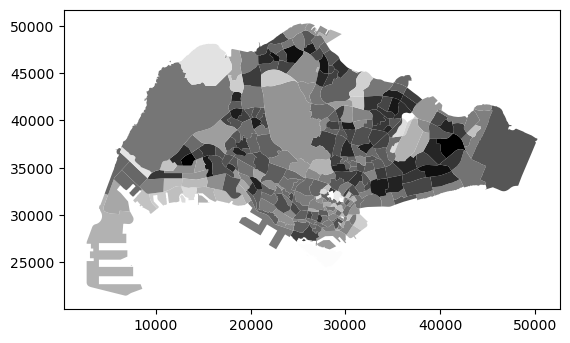

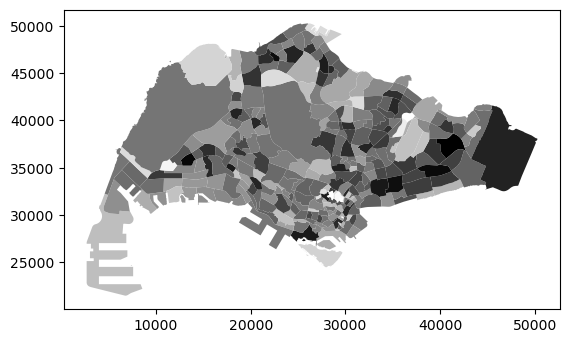

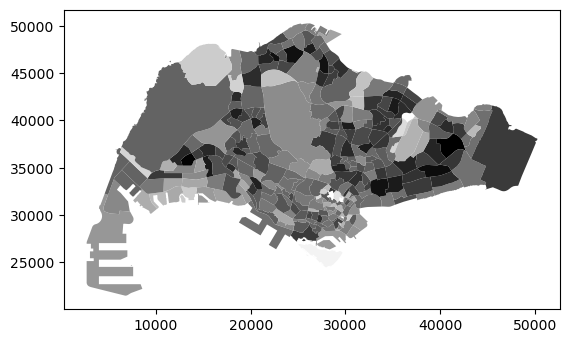

In [39]:
for col in cols8:
    df_merged['z_'+col] = standardize(df_merged[col])
    df_merged.plot('z_'+col, cmap='Greys')

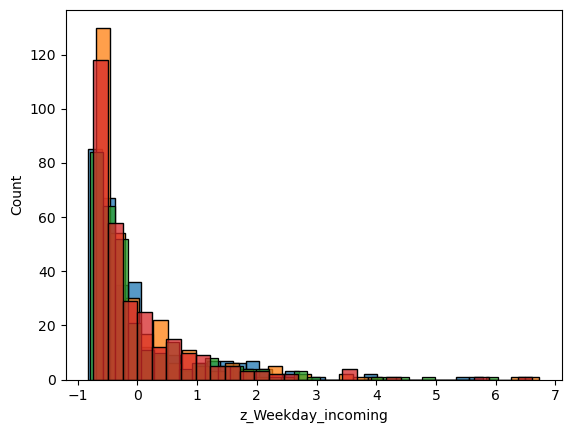

In [42]:

for col in cols:
    sns.histplot(df_merged['z_'+col])

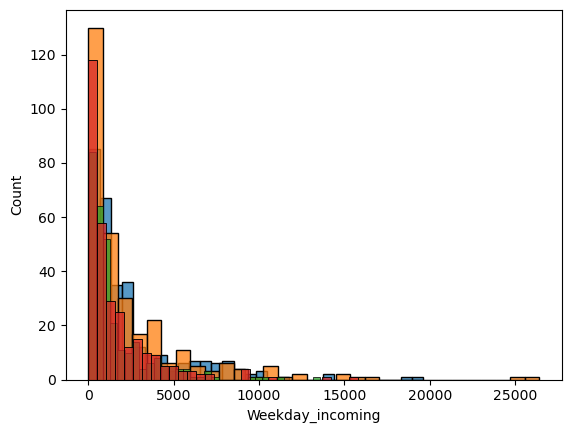

In [43]:

for col in cols:
    sns.histplot(df_merged[col])

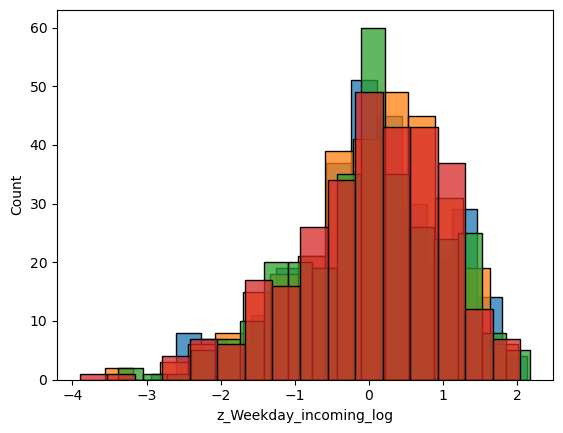

In [44]:

for col in cols:
    sns.histplot(df_merged['z_'+col+'_log'])

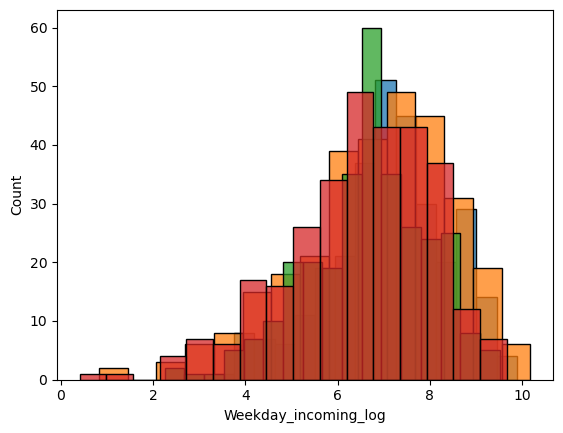

In [45]:

for col in cols:
    sns.histplot(df_merged[col+'_log'])

the above is how the data looks, now let's go checking the spatial weight

let's try to draw some lines to connect the 'neighborhood' from each subzone

In [46]:
subz.head()

,SUBZONE_N,PLN_AREA_N,REGION_N,REGION_C,geometry
0,MARINA SOUTH,MARINA SOUTH,CENTRAL REGION,CR,"POLYGON ((31495.560 30140.012, 31980.957 29671..."
1,PEARL'S HILL,OUTRAM,CENTRAL REGION,CR,"POLYGON ((29092.275 30021.888, 29119.641 30006..."
2,BOAT QUAY,SINGAPORE RIVER,CENTRAL REGION,CR,"POLYGON ((29932.332 29879.120, 29947.317 29858..."
3,HENDERSON HILL,BUKIT MERAH,CENTRAL REGION,CR,"POLYGON ((27131.276 30059.727, 27088.334 29709..."
4,REDHILL,BUKIT MERAH,CENTRAL REGION,CR,"POLYGON ((26451.027 30396.458, 26440.474 30361..."


In [48]:
subz_centers = subz.geometry.centroid 
subz_centers = {k: p for k, p in zip(subz['SUBZONE_N'], subz_centers)}
print(subz_centers['TAMPINES EAST'])

POINT (41122.54701422137 37392.38908246012)


<Axes: >

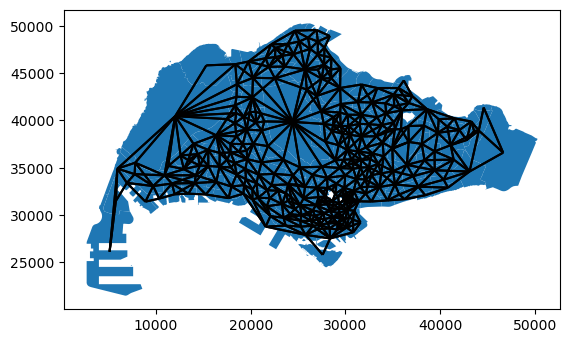

In [52]:
this_w = weights.Queen.from_dataframe(df_merged, ids='SUBZONE_N')  # based on queen contiguity

this_lines = []
for k in df_merged['SUBZONE_N']:
    ns = this_w[k]
    p0 = subz_centers[k]
    for n in ns:
        p1 = subz_centers[n]
        this_lines.append({'subz': k, 'neighbor': n, 'geometry': LineString([p0, p1])})
this_lines = pd.DataFrame.from_dict(this_lines)
this_lines = gpd.GeoDataFrame(this_lines, geometry=this_lines['geometry'], crs=subz.crs)

fig, ax = plt.subplots()
df_merged.plot(ax=ax)
this_lines.plot(ax=ax, ec='k')

In [53]:
this_w['NORTH COAST']

{'WOODLANDS WEST': 1.0,
 'SENOKO WEST': 1.0,
 'GREENWOOD PARK': 1.0,
 'SENOKO NORTH': 1.0,
 'KRANJI': 1.0}

In [54]:
len(list(this_w))

303

In [56]:
for i, k in enumerate(this_w):
    print(k)
    if i>=5:
        break

('MARINA SOUTH', {'MARINA CENTRE': 1.0, 'STRAITS VIEW': 1.0, 'BAYFRONT SUBZONE': 1.0, 'CENTRAL SUBZONE': 1.0})
("PEARL'S HILL", {'CHINATOWN': 1.0, "PEOPLE'S PARK": 1.0, 'BUKIT HO SWEE': 1.0, 'TIONG BAHRU': 1.0, 'ROBERTSON QUAY': 1.0, 'SINGAPORE GENERAL HOSPITAL': 1.0, 'CLARKE QUAY': 1.0, 'CHINA SQUARE': 1.0, 'BOAT QUAY': 1.0})
('BOAT QUAY', {"PEARL'S HILL": 1.0, 'CHINA SQUARE': 1.0, 'RAFFLES PLACE': 1.0, 'CITY HALL': 1.0, 'PHILLIP': 1.0, 'CLARKE QUAY': 1.0})
('HENDERSON HILL', {'REDHILL': 1.0, 'TIONG BAHRU STATION': 1.0, 'KAMPONG TIONG BAHRU': 1.0, 'BUKIT HO SWEE': 1.0, 'ALEXANDRA NORTH': 1.0, 'BUKIT MERAH': 1.0})
('REDHILL', {'MARGARET DRIVE': 1.0, 'ALEXANDRA HILL': 1.0, 'ALEXANDRA NORTH': 1.0, 'HENDERSON HILL': 1.0, 'BUKIT MERAH': 1.0})
('ALEXANDRA HILL', {'MEI CHIN': 1.0, 'REDHILL': 1.0, 'DEPOT ROAD': 1.0, 'ALEXANDRA NORTH': 1.0, 'MARGARET DRIVE': 1.0, 'BUKIT MERAH': 1.0, 'KENT RIDGE': 1.0, 'QUEENSWAY': 1.0})


In [58]:
def gen_lines(this_w):
    # subz and subz_centers are comming from the global variables, which may not work if this function is moved to an individual script
    this_lines = []
    for k in df_merged['SUBZONE_N']:
        ns = this_w[k]
        p0 = subz_centers[k]
        for n in ns:
            p1 = subz_centers[n]
            this_lines.append({'subz': k, 'neighbor': n, 'geometry': LineString([p0, p1])})
    this_lines = pd.DataFrame.from_dict(this_lines)
    this_lines = gpd.GeoDataFrame(this_lines, geometry=this_lines['geometry'], crs=subz.crs)
    return this_lines

In [60]:
w1 = weights.Queen.from_dataframe(df_merged, ids='SUBZONE_N')  # queen contiguity
w2 = higher_order(w1, k=2, lower_order=True)  # 2nd level queen contiguity
w3 = weights.KNN.from_dataframe(df_merged, ids='SUBZONE_N', k=10)  # k-nearest neighbors
w4 = weights.DistanceBand.from_dataframe(df_merged, ids='SUBZONE_N', threshold=2000) # distance-based (search radius/buffer)
w5 = weights.Rook.from_dataframe(df_merged, ids='SUBZONE_N')  # rook contiguity
w6 = higher_order(w5, k=2, lower_order=True)  # 2nd level rook contiguity

lines1 = gen_lines(w1)
lines2 = gen_lines(w2)
lines3 = gen_lines(w3)
lines4 = gen_lines(w4)
lines5 = gen_lines(w5)
lines6 = gen_lines(w6)

In [62]:
## some colors from Catppuccin: https://github.com/catppuccin/catppuccin
LAV = '#7287fd'
MAR = '#e64553'
BLK = '#4c4f69'
GRN = '#40a02b'
GRN2 = '#a6e3a1'
WHT = '#dce0e8'
WHT2 = '#eff1f5'

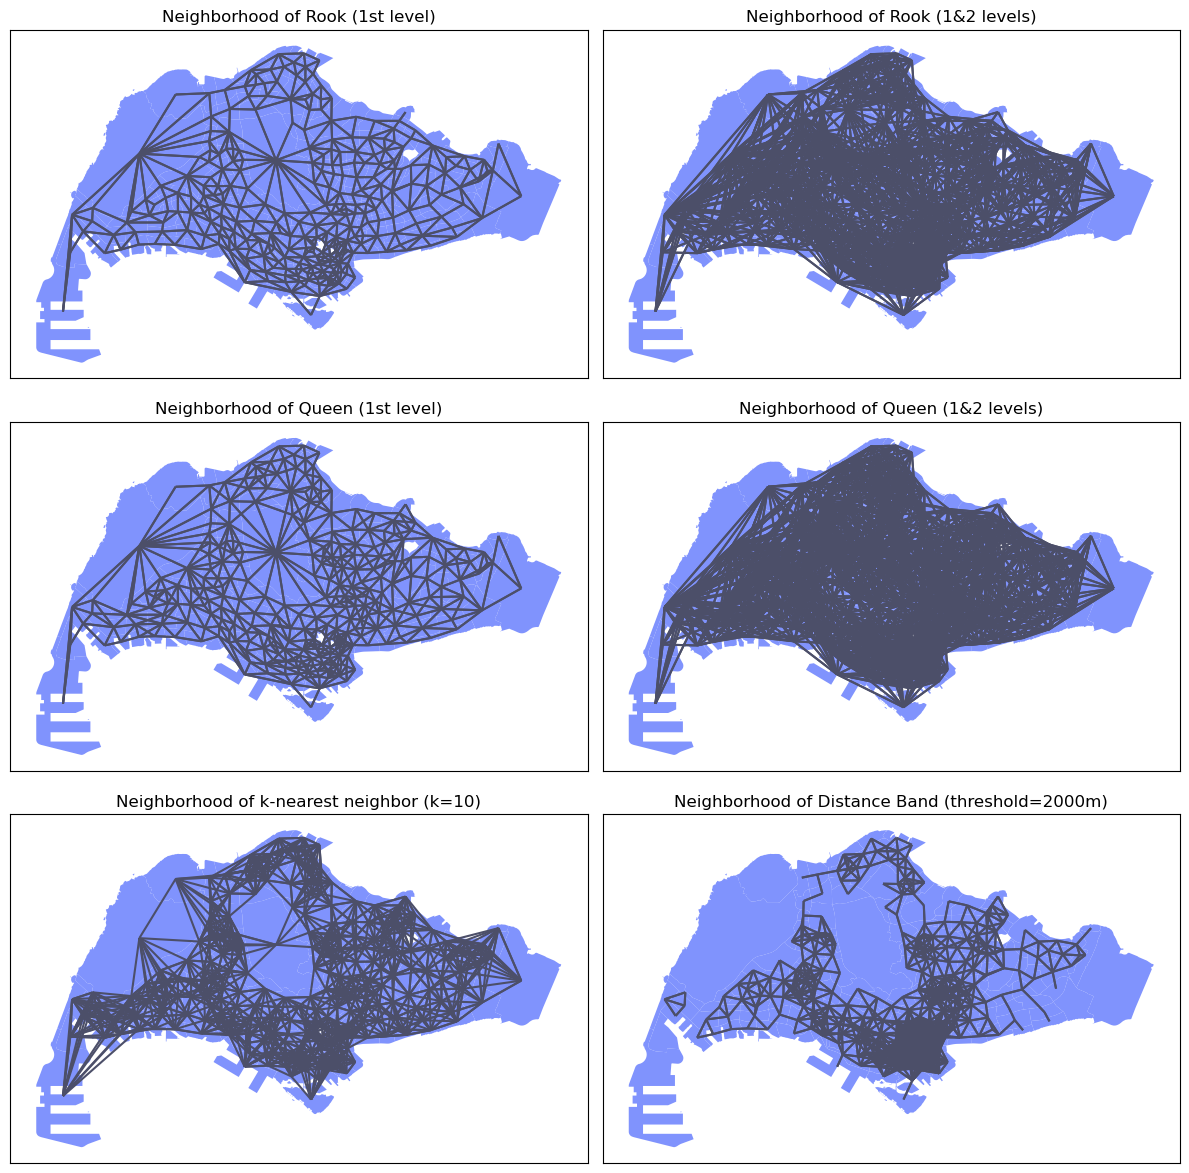

In [63]:

fig, axg = plt.subplots(3, 2, figsize=(12, 12))
axs = axg.flatten()

lines = [lines5, lines6, lines1, lines2, lines3, lines4]
spatial_defs = [
    'Rook (1st level)', 'Rook (1&2 levels)', 
    'Queen (1st level)', 'Queen (1&2 levels)', 
    'k-nearest neighbor (k=10)', 'Distance Band (threshold=2000m)'
]
for i, ln in enumerate(lines):
    ax = axs[i]
    df_merged.plot(ax=ax, fc=LAV, alpha=.9)
    ln.plot(ax=ax, ec=BLK)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Neighborhood of {}'.format(spatial_defs[i]))
plt.tight_layout()

back to Moran's I

In [105]:
w1 = weights.Queen.from_dataframe(df_merged, ids='SUBZONE_N')  # queen contiguity
w2 = higher_order(w1, k=2, lower_order=True)  # 2nd level queen contiguity
w3 = weights.KNN.from_dataframe(df_merged, ids='SUBZONE_N', k=10)  # k-nearest neighbors
w4 = weights.DistanceBand.from_dataframe(df_merged, ids='SUBZONE_N', threshold=2000) # distance-based (search radius/buffer)
w5 = weights.Rook.from_dataframe(df_merged, ids='SUBZONE_N')  # rook contiguity
w6 = higher_order(w5, k=2, lower_order=True)  # 2nd level rook contiguity

/home/benny/.pyenv/versions/miniconda3-3.9-4.12.0/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
 There are 7 islands with ids: TUAS VIEW EXTENSION, TUAS VIEW, XILIN, CHANGI AIRPORT, WESTERN WATER CATCHMENT, LIM CHU KANG, CENTRAL WATER CATCHMENT.
  warnings.warn(message)


In [140]:
# let's work with KNN
w =w3
#w.transform = 'R'  # row standardized >> can be done during the calculation of Moran's I

In [107]:
for col in cols8:
    print(col)
    df_merged['lag_'+col] = weights.lag_spatial(w, df_merged[col])
    df_merged['lag_z_'+col] = weights.lag_spatial(w, df_merged['z_'+col])

Weekday_incoming
Weekday_outgoing
Weekend_incoming
Weekend_outgoing
Weekday_incoming_log
Weekday_outgoing_log
Weekend_incoming_log
Weekend_outgoing_log


<Axes: xlabel='Weekend_outgoing_log', ylabel='lag_Weekend_outgoing_log'>

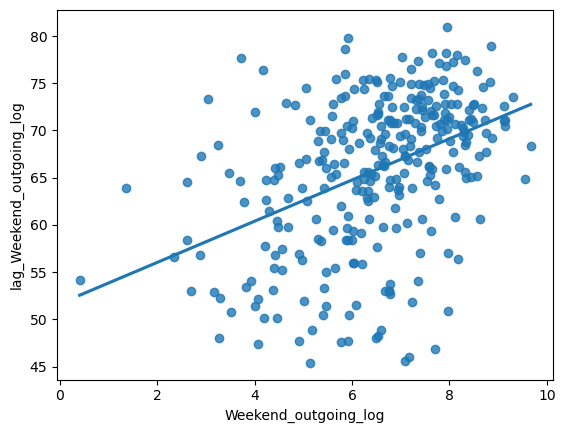

In [108]:
col = cols8[-1]
sns.regplot(x=col, y='lag_'+col, data=df_merged, ci=None)

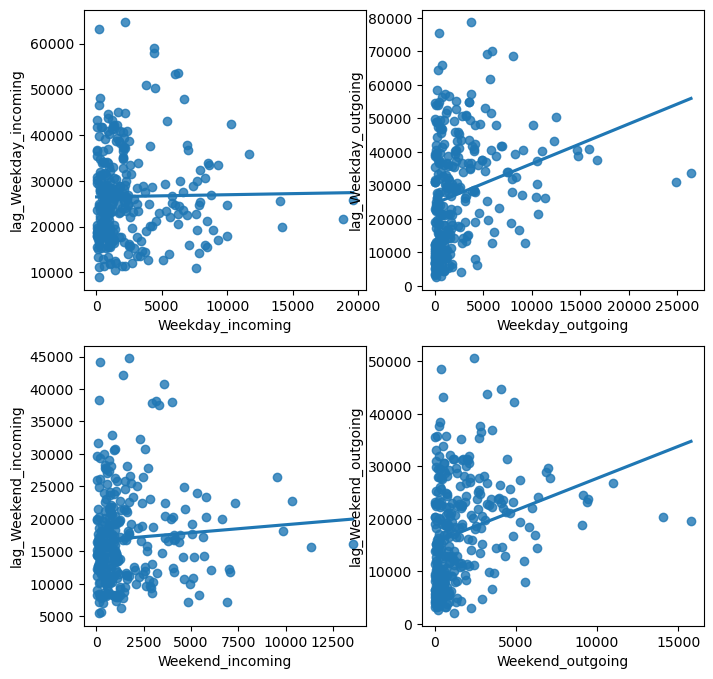

In [109]:
#col = cols[0]

# Setup the figure and axis
fig, axg = plt.subplots(2, 2, figsize=(8, 8))
axs = axg.flatten()
for i, col in enumerate(cols):
    ax = axs[i]
    # Plot values
    sns.regplot(x=col, y='lag_'+col, data=df_merged, ci=None, ax=ax)
    # Add vertical and horizontal lines
    #ax.axvline(0, c='k', alpha=0.5)
    #ax.axhline(0, c='k', alpha=0.5)

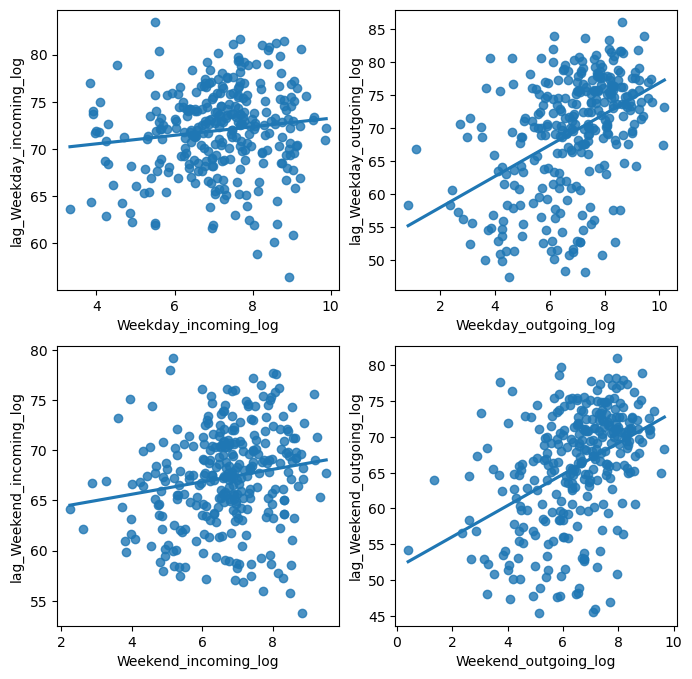

In [110]:
#col = cols[0]

# Setup the figure and axis
fig, axg = plt.subplots(2, 2, figsize=(8, 8))
axs = axg.flatten()
for i, col in enumerate(cols):
    ax = axs[i]
    # Plot values
    sns.regplot(x=col+'_log', y='lag_'+col+'_log', data=df_merged, ci=None, ax=ax)
    # Add vertical and horizontal lines
    #ax.axvline(0, c='k', alpha=0.5)
    #ax.axhline(0, c='k', alpha=0.5)

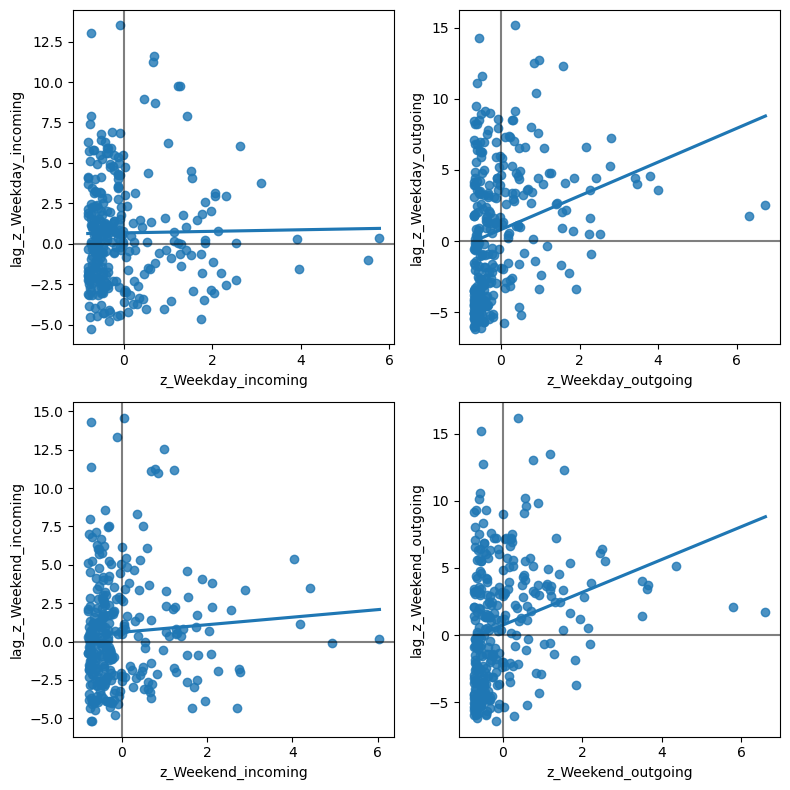

In [111]:
#col = cols[0]

# Setup the figure and axis
fig, axg = plt.subplots(2, 2, figsize=(8, 8))
axs = axg.flatten()
for i, col in enumerate(cols):
    ax = axs[i]
    # Plot values
    sns.regplot(x='z_'+col, y='lag_z_'+col, data=df_merged, ci=None, ax=ax, )
    # Add vertical and horizontal lines
    ax.axvline(0, c='k', alpha=0.5)
    ax.axhline(0, c='k', alpha=0.5)
plt.tight_layout()

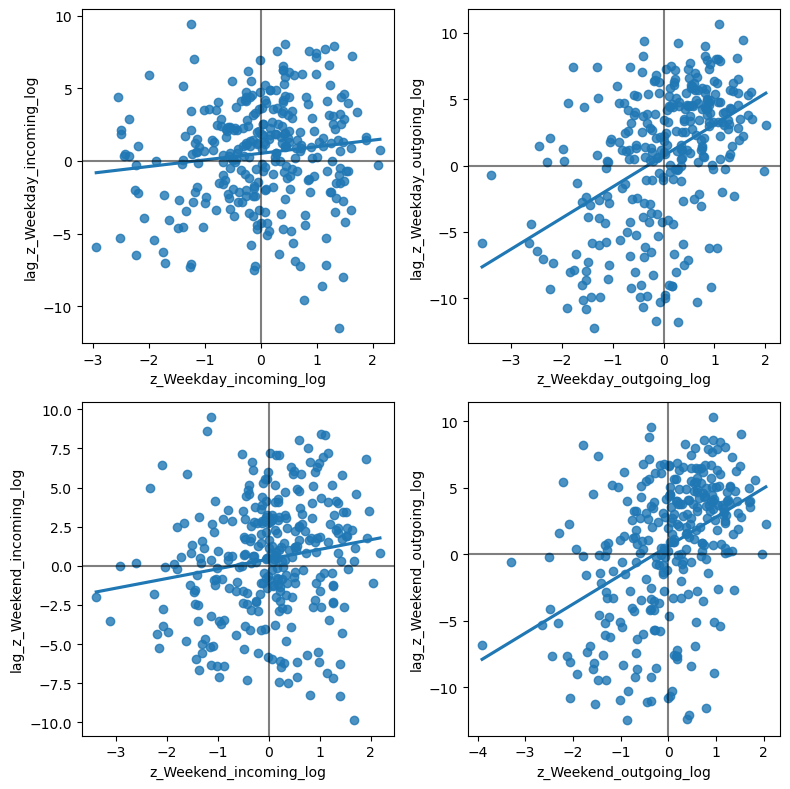

In [112]:
#col = cols[0]

# Setup the figure and axis
fig, axg = plt.subplots(2, 2, figsize=(8, 8))
axs = axg.flatten()
for i, col in enumerate(cols):
    ax = axs[i]
    # Plot values
    sns.regplot(x='z_'+col+'_log', y='lag_z_'+col+'_log', data=df_merged, ci=None, ax=ax)
    # Add vertical and horizontal lines
    ax.axvline(0, c='k', alpha=0.5)
    ax.axhline(0, c='k', alpha=0.5)
plt.tight_layout()

In [113]:
df_merged.columns

Index(['SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'REGION_C', 'geometry', 'subz',
       'Weekday_incoming', 'Weekday_outgoing', 'Weekend_incoming',
       'Weekend_outgoing', 'Weekday_incoming_log', 'Weekday_outgoing_log',
       'Weekend_incoming_log', 'Weekend_outgoing_log', 'z_Weekday_incoming',
       'z_Weekday_outgoing', 'z_Weekend_incoming', 'z_Weekend_outgoing',
       'z_Weekday_incoming_log', 'z_Weekday_outgoing_log',
       'z_Weekend_incoming_log', 'z_Weekend_outgoing_log',
       'lag_Weekday_incoming', 'lag_Weekday_incoming_log',
       'lag_z_Weekday_incoming', 'lag_z_Weekday_incoming_log',
       'lag_Weekday_outgoing', 'lag_Weekday_outgoing_log',
       'lag_z_Weekday_outgoing', 'lag_z_Weekday_outgoing_log',
       'lag_Weekend_incoming', 'lag_Weekend_incoming_log',
       'lag_z_Weekend_incoming', 'lag_z_Weekend_incoming_log',
       'lag_Weekend_outgoing', 'lag_Weekend_outgoing_log',
       'lag_z_Weekend_outgoing', 'lag_z_Weekend_outgoing_log'],
      dtype='object')

(0.12179166254992119,
 0.001,
 (<Figure size 700x700 with 1 Axes>,
  <Axes: title={'center': 'Moran Scatterplot (0.12)'}, xlabel='Attribute', ylabel='Spatial Lag'>))

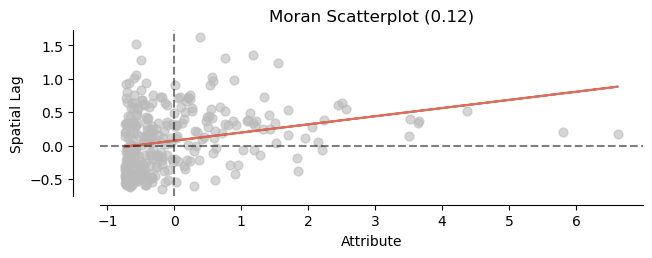

In [114]:
mi = esda.Moran(df_merged[cols[3]], w)
mi.I, mi.p_sim, moran_scatterplot(mi, zstandard=True)

In [138]:
calculates_mi = []
mi_list = {}
for i, col in enumerate(cols8):
    #ax.set_aspect('equal')
    mi = esda.Moran(df_merged[col], w, permutations=99)
    #print(mi.I, mi.p_sim, col)
    mi_list[col] = mi
    calculates_mi.append({'var': col, 'I': mi.I, 'p_sim': mi.p_sim, 'p_z_sim': mi.p_z_sim, 'p_rand': mi.p_rand, 'p_norm': mi.p_norm,})
    ## p_sim: against permutation
    ## p_z_sim: against z-standardized permutation
    ## p_rand: against uniform random distribution assumption 
    ## p_norm: against normal/gausian random distribution assumption 

calculates_mi = pd.DataFrame(calculates_mi)
calculates_mi.round(4)

,var,I,p_sim,p_z_sim,p_rand,p_norm
0,Weekday_incoming,0.0048,0.35,0.3696,0.7319,0.7351
1,Weekday_outgoing,0.1187,0.01,0.0000,0.0000,0.0000
2,Weekend_incoming,0.0246,0.14,0.1208,0.2377,0.2444
3,Weekend_outgoing,0.1218,0.01,0.0000,0.0000,0.0000
4,Weekday_incoming_log,0.0453,0.05,0.0298,0.0427,0.0427
5,Weekday_outgoing_log,0.2350,0.01,0.0000,0.0000,0.0000
6,Weekend_incoming_log,0.0620,0.01,0.0008,0.0064,0.0064
7,Weekend_outgoing_log,0.2182,0.01,0.0000,0.0000,0.0000


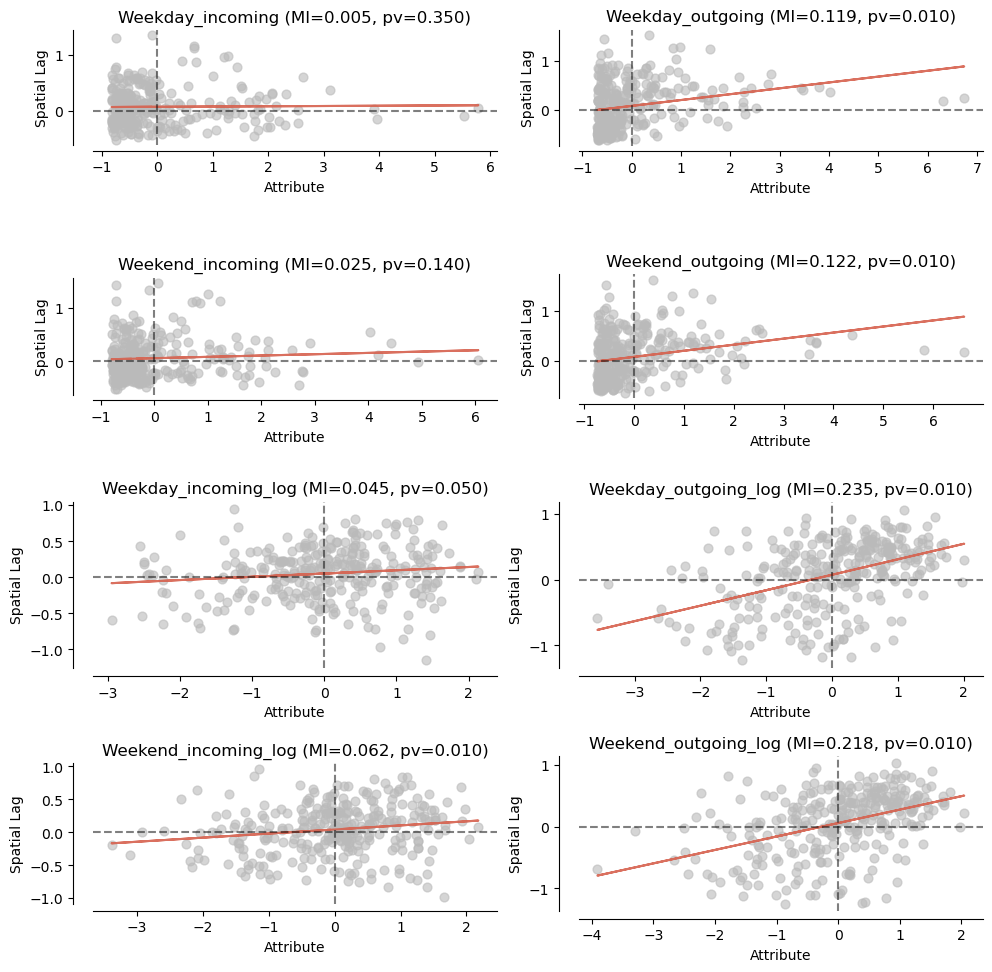

In [139]:
cols_with_log = ['Weekday_incoming', 'Weekday_outgoing', 'Weekend_incoming',
       'Weekend_outgoing', 'Weekday_incoming_log', 'Weekday_outgoing_log',
       'Weekend_incoming_log', 'Weekend_outgoing_log']

fig, axg = plt.subplots(4, 2, figsize=(10, 10))
axs = axg.flatten()

for i, col in enumerate(cols_with_log):
    ax = axs[i]
    #ax.set_aspect('equal')
    mi = mi_list[col]
    fig, ax = moran_scatterplot(mi, ax=ax, zstandard=True)
    ax.set_title('{} (MI={:.3f}, pv={:.3f})'.format(col, mi.I, mi.p_sim))
plt.tight_layout()

the top four plots (original values) 
- have lower I value, 
- incoming are not significant
- outgoing are significant

the bottom four plots (log-transformed)
- I values are higher
- p-values indicate all are significant
- outgoing's I are higher than incoming

These implied that in the morning commuting hours (6am-9am), the outgoing volumes are significantly clustered.  

how about if we use other spatial weights? or knn with different k? 